# **Import Libraries**

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

plt.style.use('ggplot')

## **Load Dataset**

In [22]:
df = pd.read_csv(r"C:\Users\afzal\Desktop\DataSets\Instagram_Analytics.csv")

df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,post_hour,day_of_week,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,6,Saturday,194,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,15,Friday,449,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,16,Thursday,114,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,3,Thursday,91,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,9,Friday,154,8,5,21,5350,8503,0.0221,155,112,9,low


## **Dataset Overview**

In [23]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (29999, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_category          29999 non-null  object 
 6   traffic_source            29999 non-null  object 
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  object 
 9   post_date                 29999 non-null  object 
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  object 
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  

,account_id,follower_count,has_call_to_action,post_hour,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,10.567819,10278.305477,0.348778,11.499417,287.653588,8.521917,14.426614,42.517284,6272.475449,8466.952498,0.042107,502.152805,120.081169,7.987933
std,5.763952,6691.862669,0.476592,6.900587,317.647682,10.116505,16.420899,47.808844,4985.877059,6825.900355,0.024095,290.364038,11.009108,2.828130
min,1.000000,3083.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,268.000000,327.000000,0.000000,0.000000,70.000000,0.000000
25%,6.000000,5824.000000,0.000000,6.000000,104.000000,3.000000,5.000000,15.000000,3058.000000,4102.000000,0.024000,251.000000,113.000000,6.000000
50%,11.000000,9044.000000,0.000000,12.000000,199.000000,6.000000,10.000000,29.000000,4913.000000,6595.000000,0.040600,501.000000,120.000000,8.000000
75%,16.000000,10739.000000,1.000000,17.000000,363.000000,11.000000,19.000000,54.000000,7863.000000,10620.500000,0.057000,755.000000,127.000000,10.000000
max,20.000000,31095.000000,1.000000,23.000000,10632.000000,339.000000,516.000000,1542.000000,73339.000000,105203.000000,0.271000,1000.000000,166.000000,21.000000


## **Missing Values**

In [24]:
df.isnull().sum()

post_id                     0
account_id                  0
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_datetime               0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
shares                      0
saves                       0
reach                       0
impressions                 0
engagement_rate             0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
dtype: int64

## **Convert Date Columns**

In [27]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'])

df['year'] = df['post_datetime'].dt.year
df['month'] = df['post_datetime'].dt.month_name()
df['day'] = df['post_datetime'].dt.day_name()
df['hour'] = df['post_datetime'].dt.hour

## **Feature Engineering**

## Engagement Score

In [29]:
df['Engagement'] = (
    df['likes']
    + df['comments']
    + df['shares']
    + df['saves']
)

## Engagement Rate

In [31]:
df['Engagement Rate'] = (
    df['Engagement']
    /
    df['reach']
) * 100

## Engagement Distribution

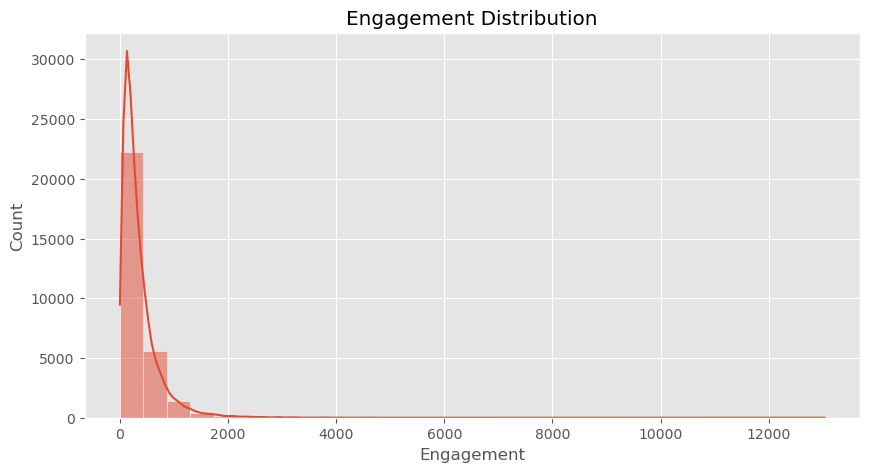

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Engagement'],
    bins=30,
    kde=True
)

plt.title("Engagement Distribution")
plt.show()

## Media Type Analysis

In [35]:
media_perf = (
    df.groupby('media_type')
    ['Engagement']
    .mean()
    .sort_values(ascending=False)
)

media_perf

media_type
image       355.533663
carousel    351.855557
reel        351.055742
Name: Engagement, dtype: float64

## Visualization

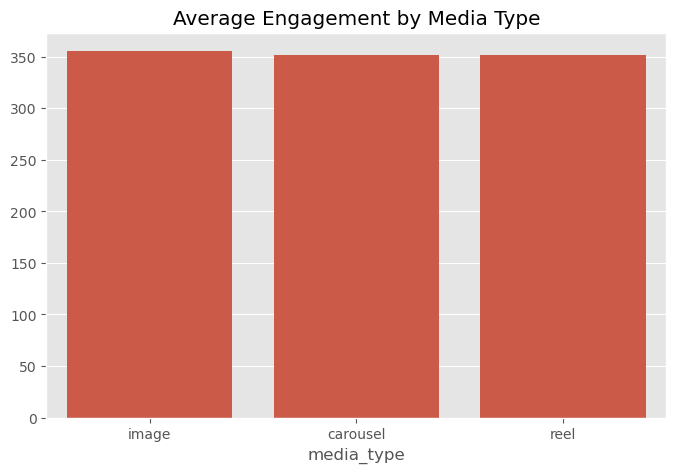

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=media_perf.index,
    y=media_perf.values
)

plt.title("Average Engagement by Media Type")

plt.show()

## **Follower Growth Analysis**

In [39]:
growth_media = (
    df.groupby('media_type')['followers_gained']
    .mean()
    .sort_values(ascending=False)
)

print(growth_media)

media_type
carousel    506.861014
image       500.914312
reel        497.416387
Name: followers_gained, dtype: float64


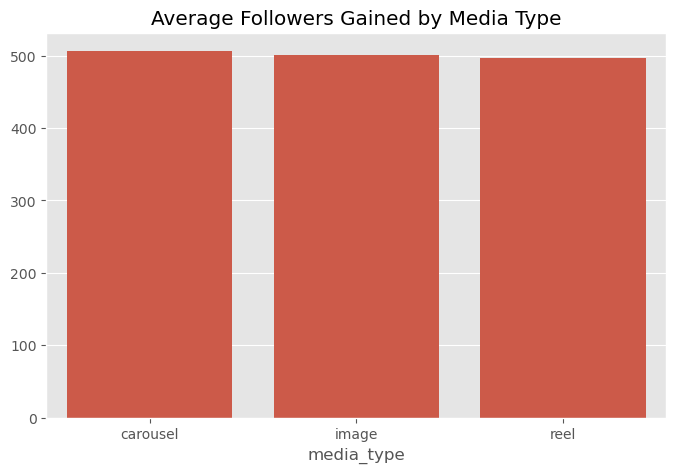

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=growth_media.index,
    y=growth_media.values
)

plt.title("Average Followers Gained by Media Type")
plt.show()

## **Best Posting Day**

In [46]:
day_performance = (
    df.groupby('day_of_week')['Engagement']
    .mean()
)
day_performance

day_of_week
Friday       356.992413
Monday       355.552232
Saturday     343.346262
Sunday       362.311772
Thursday     348.975178
Tuesday      360.567915
Wednesday    344.319051
Name: Engagement, dtype: float64

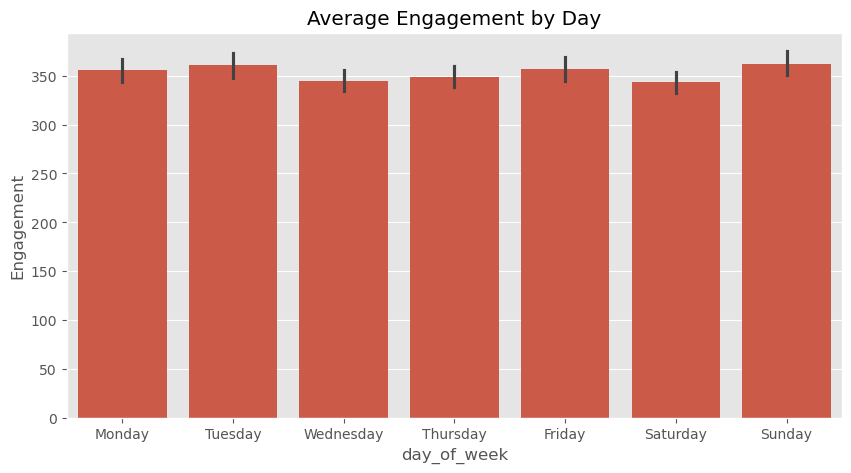

In [45]:
order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='day_of_week',
    y='Engagement',
    order=order
)

plt.title("Average Engagement by Day")

plt.show()

## **Best Posting Hour**

In [48]:
hour_performance = (
    df.groupby('post_hour')['Engagement']
    .mean()
)

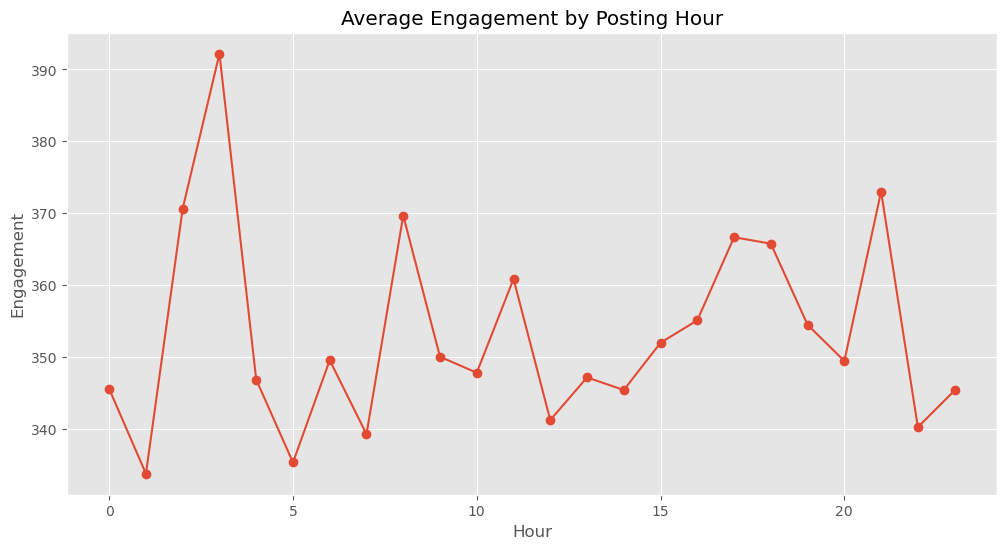

In [49]:
plt.figure(figsize=(12,6))

hour_performance.plot(marker='o')

plt.title("Average Engagement by Posting Hour")

plt.xlabel("Hour")

plt.ylabel("Engagement")

plt.show()

## **Best Posting Time Heatmap**

In [51]:
heatmap_data = pd.pivot_table(
    df,
    values='Engagement',
    index='day_of_week',
    columns='post_hour',
    aggfunc='mean'
)

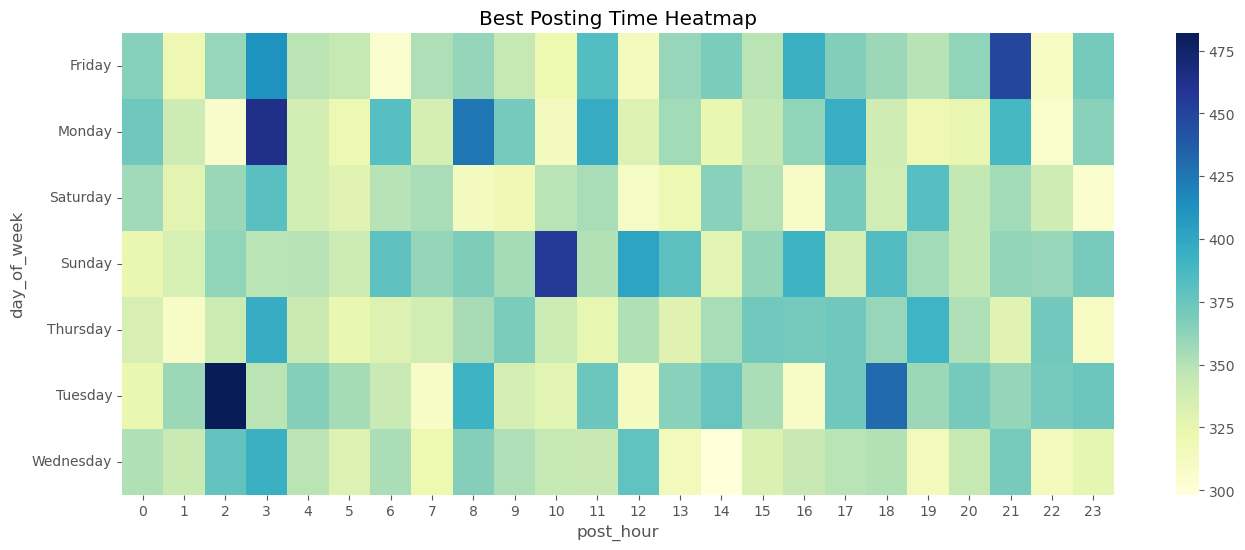

In [52]:
plt.figure(figsize=(16,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title("Best Posting Time Heatmap")

plt.show()

## **Content Category Analysis**

In [54]:
category_perf = (
    df.groupby('content_category')['Engagement']
    .mean()
    .sort_values(ascending=False)
)

print(category_perf)

content_category
Fashion        363.917601
Music          358.455877
Photography    356.433278
Comedy         355.179322
Fitness        354.663116
Beauty         354.502878
Food           353.430233
Lifestyle      350.497514
Travel         343.215633
Technology     340.797025
Name: Engagement, dtype: float64


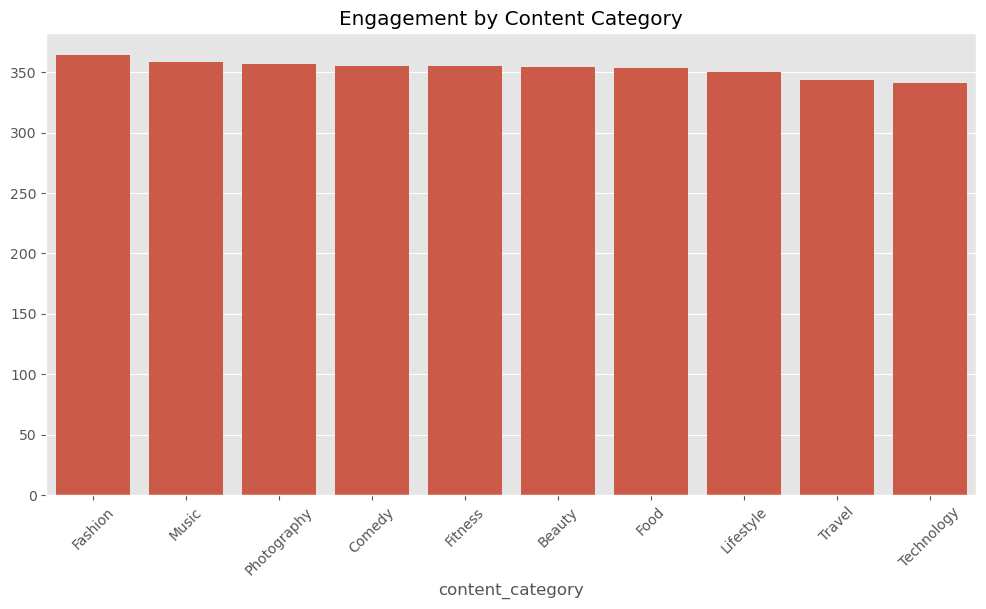

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_perf.index,
    y=category_perf.values
)

plt.xticks(rotation=45)

plt.title("Engagement by Content Category")

plt.show()

## **Traffic Source Analysis**

In [56]:
traffic_perf = (
    df.groupby('traffic_source')['Engagement']
    .mean()
    .sort_values(ascending=False)
)

print(traffic_perf)

traffic_source
External      362.167033
Profile       358.078597
Reels Feed    355.038599
Hashtags      351.501086
Explore       348.741691
Home Feed     343.254291
Name: Engagement, dtype: float64


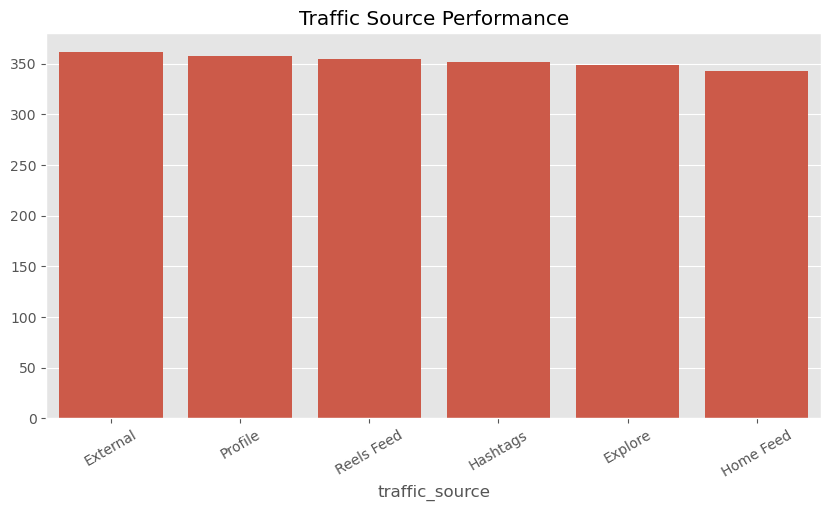

In [57]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=traffic_perf.index,
    y=traffic_perf.values
)

plt.title("Traffic Source Performance")

plt.xticks(rotation=30)

plt.show()

## **Call To Action Analysis**

In [58]:
cta_perf = (
    df.groupby('has_call_to_action')['Engagement']
    .mean()
)

print(cta_perf)

has_call_to_action
0    353.677416
1    352.077511
Name: Engagement, dtype: float64


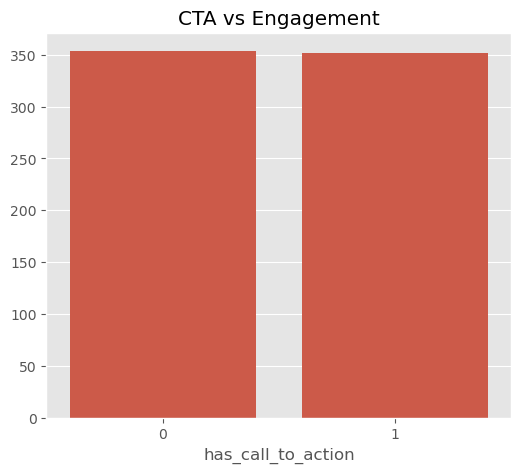

In [59]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=cta_perf.index.astype(str),
    y=cta_perf.values
)

plt.title("CTA vs Engagement")

plt.show()

## **Hashtag Analysis**

In [60]:
correlation = df[
    ['hashtags_count','Engagement']
].corr()

print(correlation)

                hashtags_count  Engagement
hashtags_count        1.000000    0.006585
Engagement            0.006585    1.000000


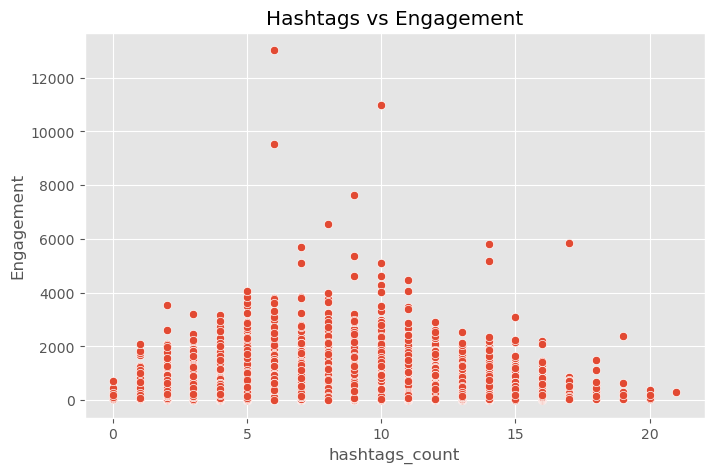

In [62]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='hashtags_count',
    y='Engagement'
)

plt.title("Hashtags vs Engagement")

plt.show()

## **Caption Length Analysis**

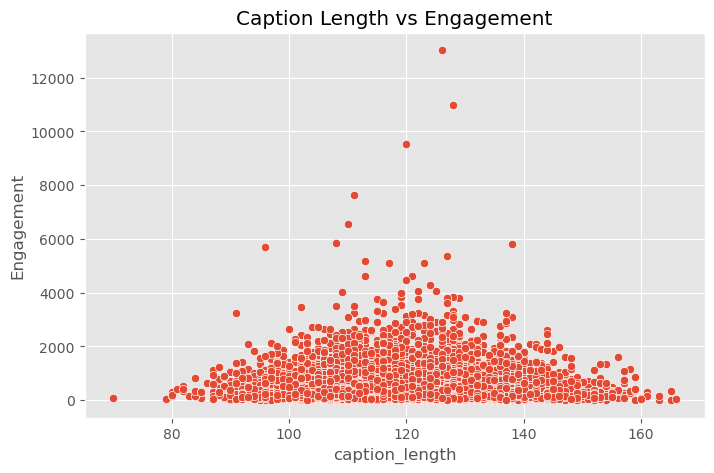

In [64]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='caption_length',
    y='Engagement'
)

plt.title("Caption Length vs Engagement")

plt.show()

## **Followers Growth Analysis**

In [65]:
category_growth = (
    df.groupby('content_category')['followers_gained']
    .mean()
    .sort_values(ascending=False)
)

print(category_growth)

content_category
Music          512.873793
Lifestyle      508.992377
Beauty         505.479512
Photography    503.241516
Food           503.049502
Travel         503.033019
Comedy         498.470508
Fashion        497.576796
Fitness        497.250000
Technology     491.641983
Name: followers_gained, dtype: float64


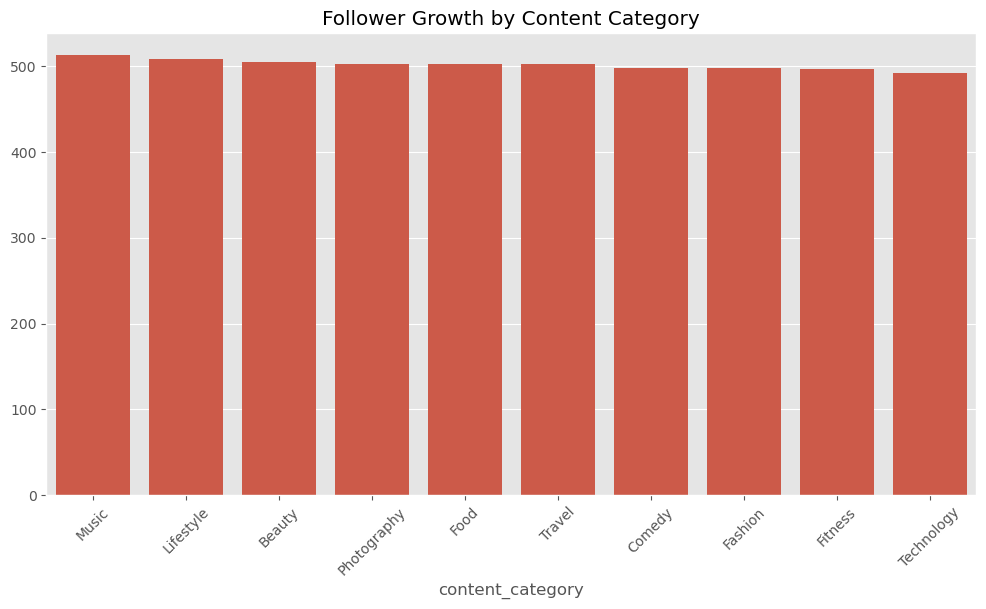

In [66]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_growth.index,
    y=category_growth.values
)

plt.xticks(rotation=45)

plt.title("Follower Growth by Content Category")

plt.show()

## **Top 10 Posts**

In [68]:
top_posts = df.sort_values(
    by='Engagement',
    ascending=False
).head(10)

top_posts[
[
'post_id',
'media_type',
'content_category',
'Engagement',
'followers_gained'
]
]

,post_id,media_type,content_category,Engagement,followers_gained
29801,IG0029802,image,Food,13029,690
13720,IG0013721,reel,Photography,10992,513
28355,IG0028356,carousel,Fashion,9516,577
10078,IG0010079,carousel,Food,7641,694
12426,IG0012427,carousel,Comedy,6555,306
3901,IG0003902,image,Food,5853,828
7842,IG0007843,reel,Photography,5805,584
3108,IG0003109,image,Fashion,5679,558
2856,IG0002857,carousel,Technology,5376,539
13981,IG0013982,carousel,Fashion,5169,640


## **Performance Bucket Analysis**

In [69]:
bucket = (
    df.groupby('performance_bucket_label')
    ['Engagement']
    .mean()
)

print(bucket)

performance_bucket_label
high      431.885067
low       147.285600
medium    285.692359
viral     547.605600
Name: Engagement, dtype: float64


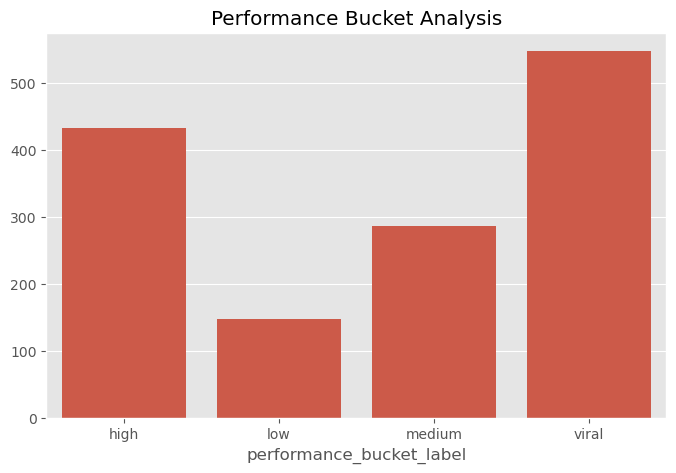

In [70]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=bucket.index,
    y=bucket.values
)

plt.title("Performance Bucket Analysis")

plt.show()

## **Correlation Matrix**

In [72]:
numerical_cols = [
    'follower_count',
    'likes',
    'comments',
    'shares',
    'saves',
    'reach',
    'impressions',
    'engagement_rate',
    'followers_gained',
    'caption_length',
    'hashtags_count',
    'Engagement'
]

corr = df[numerical_cols].corr()

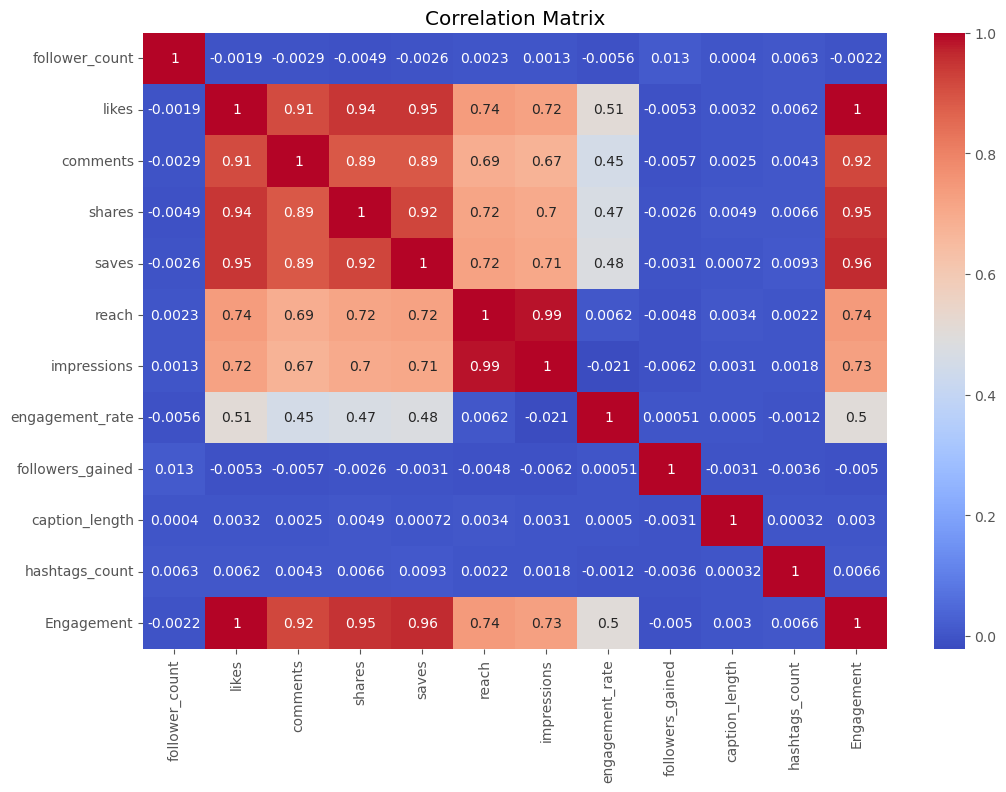

In [73]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

## **Key Insights**

In [75]:
print("""
1. Identify highest-performing media type.

2. Identify best posting day.

3. Identify best posting hour.

4. Determine content category with highest engagement.

5. Determine category driving follower growth.

6. Evaluate CTA effectiveness.

7. Evaluate hashtag effectiveness.

8. Recommend optimal posting schedule.""")


1. Identify highest-performing media type.

2. Identify best posting day.

3. Identify best posting hour.

4. Determine content category with highest engagement.

5. Determine category driving follower growth.

6. Evaluate CTA effectiveness.

7. Evaluate hashtag effectiveness.

8. Recommend optimal posting schedule.


## **Recommendations**

In [76]:
print("""
1. Focus on top-performing media types.

2. Post during highest engagement hours.

3. Increase content in best-performing categories.

4. Use CTA in high-value educational posts.

5. Optimize hashtags based on engagement patterns.

6. Replicate characteristics of top 10 posts.

7. Create a weekly content calendar around peak engagement periods.""")


1. Focus on top-performing media types.

2. Post during highest engagement hours.

3. Increase content in best-performing categories.

4. Use CTA in high-value educational posts.

5. Optimize hashtags based on engagement patterns.

6. Replicate characteristics of top 10 posts.

7. Create a weekly content calendar around peak engagement periods.
